In [7]:
from scipy.io import loadmat

data = loadmat("../data/mill.mat")

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'mill'])


In [8]:
mill = data['mill']

print(type(mill))
print(mill.shape)


<class 'numpy.ndarray'>
(1, 167)


In [9]:
print(mill)

[[(array([[1]], dtype=uint8), array([[1]], dtype=uint8), array([[0]], dtype=uint8), array([[2]], dtype=uint8), array([[1.5]]), array([[0.5]]), array([[1]], dtype=uint8), array([[-0.01708984],
         [ 0.26367188],
         [ 0.20751953],
         ...,
         [-0.80810547],
         [-0.73242188],
         [-0.57617188]], shape=(9000, 1)), array([[0.625     ],
         [0.81054688],
         [0.78125   ],
         ...,
         [1.38183594],
         [1.30371094],
         [1.52832031]], shape=(9000, 1)), array([[0.078125  ],
         [0.08544922],
         [0.078125  ],
         ...,
         [0.27587891],
         [0.52246094],
         [0.37841797]], shape=(9000, 1)), array([[0.31494141],
         [0.30151367],
         [0.30395508],
         ...,
         [0.3125    ],
         [0.31738281],
         [0.3112793 ]], shape=(9000, 1)), array([[0.08728027],
         [0.0982666 ],
         [0.09216309],
         ...,
         [0.10131836],
         [0.12756348],
         [0.12329102]

In [10]:
sample = mill[0,0]

print(type(sample))
print(len(sample))

<class 'numpy.void'>
13


In [11]:
sample = mill[0,0]

for i in range(13):
    print(f"Field {i}:")
    print(sample[i].shape)
    print("-"*30)

Field 0:
(1, 1)
------------------------------
Field 1:
(1, 1)
------------------------------
Field 2:
(1, 1)
------------------------------
Field 3:
(1, 1)
------------------------------
Field 4:
(1, 1)
------------------------------
Field 5:
(1, 1)
------------------------------
Field 6:
(1, 1)
------------------------------
Field 7:
(9000, 1)
------------------------------
Field 8:
(9000, 1)
------------------------------
Field 9:
(9000, 1)
------------------------------
Field 10:
(9000, 1)
------------------------------
Field 11:
(9000, 1)
------------------------------
Field 12:
(9000, 1)
------------------------------


In [12]:
print(mill.dtype.names)


('case', 'run', 'VB', 'time', 'DOC', 'feed', 'material', 'smcAC', 'smcDC', 'vib_table', 'vib_spindle', 'AE_table', 'AE_spindle')


In [13]:
import pandas as pd
import numpy as np

rows = []

for i in range(mill.shape[1]):
    sample = mill[0, i]

    row = {
        "case": int(sample["case"][0][0]),
        "run": int(sample["run"][0][0]),
        "VB": float(sample["VB"][0][0]),
        "time": float(sample["time"][0][0]),
        "DOC": float(sample["DOC"][0][0]),
        "feed": float(sample["feed"][0][0]),
        "material": int(sample["material"][0][0]),

        # Mean values of sensor signals
        "smcAC_mean": np.mean(sample["smcAC"]),
        "smcDC_mean": np.mean(sample["smcDC"]),
        "vib_table_mean": np.mean(sample["vib_table"]),
        "vib_spindle_mean": np.mean(sample["vib_spindle"]),
        "AE_table_mean": np.mean(sample["AE_table"]),
        "AE_spindle_mean": np.mean(sample["AE_spindle"])
    }

    rows.append(row)

df = pd.DataFrame(rows)

df.head()

,case,run,VB,time,DOC,feed,material,smcAC_mean,smcDC_mean,vib_table_mean,vib_spindle_mean,AE_table_mean,AE_spindle_mean
0,1,1,0.00,2.0,1.5,0.5,1,-0.164255,5.438449,1.612179,0.550384,0.169631,0.188504
1,1,2,NaN,4.0,1.5,0.5,1,-0.166147,5.565662,1.543231,0.548626,0.173653,0.188343
2,1,3,NaN,6.0,1.5,0.5,1,-0.167512,5.636371,1.466644,0.556704,0.175478,0.209612
3,1,4,0.11,7.0,1.5,0.5,1,-0.162823,5.827789,1.427711,0.509748,0.187832,0.216906
4,1,5,NaN,11.0,1.5,0.5,1,-0.162127,6.554653,1.534803,0.477526,0.197414,0.228438


In [14]:
df = df.dropna(subset=["VB"])

print(df.shape)
df.head()

(146, 13)


,case,run,VB,time,DOC,feed,material,smcAC_mean,smcDC_mean,vib_table_mean,vib_spindle_mean,AE_table_mean,AE_spindle_mean
0,1,1,0.00,2.0,1.5,0.5,1,-0.164255,5.438449,1.612179,0.550384,0.169631,0.188504
3,1,4,0.11,7.0,1.5,0.5,1,-0.162823,5.827789,1.427711,0.509748,0.187832,0.216906
5,1,6,0.20,15.0,1.5,0.5,1,-0.157327,7.148232,0.930610,0.460114,0.207657,0.218572
6,1,7,0.24,19.0,1.5,0.5,1,-0.157893,7.490556,1.494715,0.401415,0.187047,0.285886
7,1,8,0.29,22.0,1.5,0.5,1,-0.177523,7.818537,0.862927,0.406560,0.236334,0.269142


In [15]:
X = df.drop(columns=["VB"])
y = df["VB"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 0.0877609604721268
RMSE: 0.11556159180727076
R² Score: 0.5933539711763152


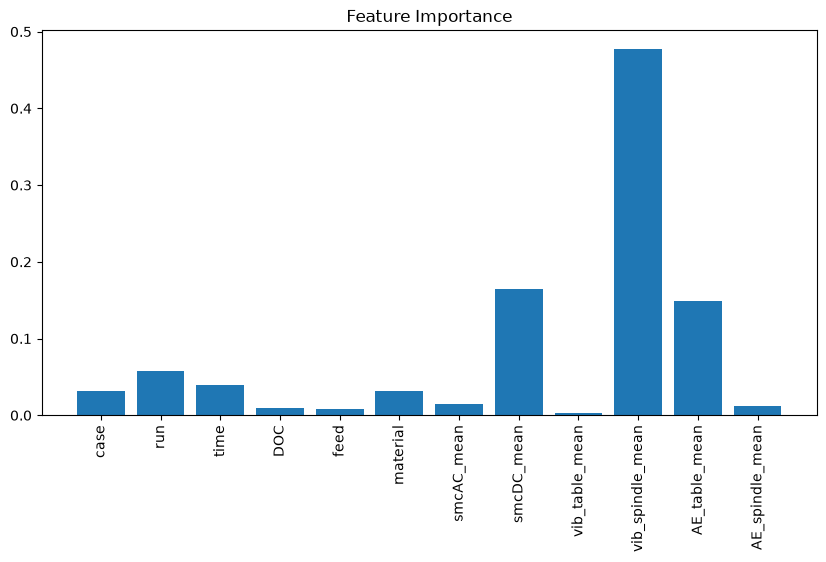

In [20]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(X.columns, importance)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

In [26]:
import joblib

joblib.dump(model, "../models/xgboost_tool_wear.pkl")

['../models/xgboost_tool_wear.pkl']

In [27]:
joblib.dump(model, "../models/xgboost_tool_wear.pkl")

['../models/xgboost_tool_wear.pkl']

In [30]:
joblib.dump(model, "../models/xgboost_tool_wear.pkl")

['../models/xgboost_tool_wear.pkl']

In [32]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import mlflow

print(mlflow.__version__)

3.14.0


In [37]:
import mlflow
from sklearn.metrics import r2_score, mean_absolute_error

mlflow.set_experiment("Tool_Wear_Prediction")

with mlflow.start_run():

    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 5)

    mlflow.log_metric("R2", r2_score(y_test, y_pred))
    mlflow.log_metric("MAE", mean_absolute_error(y_test, y_pred))

    mlflow.log_artifact("../models/xgboost_tool_wear.pkl")

print("Experiment logged successfully!")

2026/06/24 09:16:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/24 09:16:25 INFO mlflow.store.db.utils: Updating database tables
2026/06/24 09:16:30 INFO mlflow.tracking.fluent: Experiment with name 'Tool_Wear_Prediction' does not exist. Creating a new experiment.


Experiment logged successfully!


In [38]:
import mlflow
from sklearn.metrics import r2_score, mean_absolute_error

mlflow.set_experiment("Tool_Wear_Prediction")

with mlflow.start_run():
    mlflow.log_metric("R2_score", r2_score(y_test, y_pred))

In [39]:
pip install fastapi uvicorn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
